# Movie Recommender System: Content-Based -> Hybrid -> Cross-Lingual

We build a recommender from TMDB-style movie metadata. The path is deliberately staged: strong lexical content matching, rank-fused hybrid retrieval, then multilingual query support when a dense multilingual model is available.

In [1]:
import os
import re
import io
import glob
import math
import html
import difflib
import warnings
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display
from scipy import sparse
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer, normalize

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", font_scale=1.0)

SEED = 42
N_COMPONENTS = 128
USE_SENTENCE_TRANSFORMER = True
EMBEDDING_MODEL_NAME = "intfloat/multilingual-e5-small"  # 94-language, 384-d embedding model when available

## Load And Repair

One overview contains raw carriage returns inside an unquoted field. Reading bytes and replacing `\r` before pandas parsing preserves that movie instead of dropping rows.

In [2]:
EXPECTED_COLUMNS = [
    "Release_Date", "Title", "Overview", "Popularity", "Vote_Count",
    "Vote_Average", "Original_Language", "Genre", "Poster_Url"
]

LANGUAGE_NAMES = {
    "en": "English", "ja": "Japanese", "es": "Spanish", "fr": "French", "ko": "Korean",
    "zh": "Chinese", "cn": "Chinese", "it": "Italian", "ru": "Russian", "de": "German",
    "pt": "Portuguese", "hi": "Hindi", "da": "Danish", "no": "Norwegian", "sv": "Swedish",
    "nl": "Dutch", "th": "Thai", "pl": "Polish", "id": "Indonesian", "tr": "Turkish"
}


def find_input_csv():
    candidates = [Path(p) for p in glob.glob("/kaggle/input/**/*.csv", recursive=True)]
    candidates += [Path(p) for p in glob.glob("*.csv")]
    if not candidates:
        raise FileNotFoundError("No CSV found. Attach the dataset in Kaggle or place the CSV beside this notebook.")

    def score(path):
        name = path.name.lower()
        keyword_score = sum(token in name for token in ["movie", "moviedb", "tmdb", "netflix"])
        size_score = min(path.stat().st_size / 1e8, 1.0)
        return keyword_score + size_score

    return max(candidates, key=score)


def read_movie_csv(path):
    text = Path(path).read_bytes().decode("utf-8", errors="replace").replace("\r", " ")
    return pd.read_csv(io.StringIO(text), engine="python")


def split_genres(value):
    return [g.strip() for g in str(value).split(",") if g.strip()]


DATA_PATH = find_input_csv()
raw = read_movie_csv(DATA_PATH)
missing = [col for col in EXPECTED_COLUMNS if col not in raw.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

df = raw[EXPECTED_COLUMNS].drop_duplicates().copy()
for col in ["Popularity", "Vote_Count", "Vote_Average"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Release_Date"] = pd.to_datetime(df["Release_Date"], errors="coerce")
df = df.dropna(subset=EXPECTED_COLUMNS).reset_index(drop=True)
df["Vote_Count"] = df["Vote_Count"].astype(int)
df["year"] = df["Release_Date"].dt.year.astype(int)
df["genres"] = df["Genre"].map(split_genres)
df["primary_genre"] = df["genres"].map(lambda gs: gs[0] if gs else "Unknown")
df["language_name"] = df["Original_Language"].map(LANGUAGE_NAMES).fillna(df["Original_Language"])

C = df["Vote_Average"].mean()
m = df["Vote_Count"].quantile(0.75)
df["bayes_rating"] = (df["Vote_Count"] / (df["Vote_Count"] + m)) * df["Vote_Average"] + (m / (df["Vote_Count"] + m)) * C
df["bayes_norm"] = df["bayes_rating"].rank(pct=True)
df["popularity_norm"] = np.log1p(df["Popularity"]).rank(pct=True)
df["vote_norm"] = np.log1p(df["Vote_Count"]).rank(pct=True)
df["quality_score"] = 0.60 * df["bayes_norm"] + 0.25 * df["popularity_norm"] + 0.15 * df["vote_norm"]

df.head(3)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,year,genres,primary_genre,language_name,bayes_rating,bayes_norm,popularity_norm,vote_norm,quality_score
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to separate his normal life from the high-stakes of being a super-hero. ...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4irTY1GPXvft6k4YLjm.jpg,2021,"[Action, Adventure, Science Fiction]",Action,English,8.051842,0.995523,1.000000,0.973441,0.993330
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman uncovers corruption in Gotham City that connects to his own family whil...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R36Fpooo50r9T25onhq.jpg,2022,"[Crime, Mystery, Thriller]",Crime,English,7.195844,0.944948,0.999898,0.712425,0.923807
2,2022-02-25,No Exit,"Stranded at a rest stop in the mountains during a blizzard, a recovering addict discovers a kidnapped child hidden i...",2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKlPGmWs0kGfuhNF4w5l.jpg,2022,[Thriller],Thriller,English,6.428170,0.391472,0.999796,0.217462,0.517452


In [3]:
print(f"Loaded {len(df):,} movies from: {DATA_PATH}")
print(f"Release years: {df['year'].min()}-{df['year'].max()}")
print(f"Languages: {df['Original_Language'].nunique()} | Genres: {len(set(g for gs in df['genres'] for g in gs))}")
print(f"Duplicate title rows kept: {df.duplicated('Title', keep=False).sum():,} (mostly remakes or same-title films)")

display(df[["Title", "year", "Original_Language", "Genre", "Vote_Average", "Vote_Count", "Popularity"]].head(10))

Loaded 9,827 movies from: mymoviedb.csv
Release years: 1902-2024
Languages: 43 | Genres: 19
Duplicate title rows kept: 602 (mostly remakes or same-title films)


,Title,year,Original_Language,Genre,Vote_Average,Vote_Count,Popularity
0,Spider-Man: No Way Home,2021,en,"Action, Adventure, Science Fiction",8.3,8940,5083.954
1,The Batman,2022,en,"Crime, Mystery, Thriller",8.1,1151,3827.658
2,No Exit,2022,en,Thriller,6.3,122,2618.087
3,Encanto,2021,en,"Animation, Comedy, Family, Fantasy",7.7,5076,2402.201
4,The King's Man,2021,en,"Action, Adventure, Thriller, War",7.0,1793,1895.511
5,The Commando,2022,en,"Action, Crime, Thriller",6.6,33,1750.484
6,Scream,2022,en,"Horror, Mystery, Thriller",6.8,821,1675.161
7,Kimi,2022,en,Thriller,6.3,206,1601.782
8,Fistful of Vengeance,2022,en,"Action, Crime, Fantasy",5.3,114,1594.013
9,Eternals,2021,en,Science Fiction,7.2,4726,1537.406


## Dataset Pulse

The catalog is English-heavy, but it contains meaningful Japanese, Spanish, French, Korean, Chinese, Italian, Russian, and German coverage. Vote counts and popularity are heavily skewed, so we use log/rank transforms.

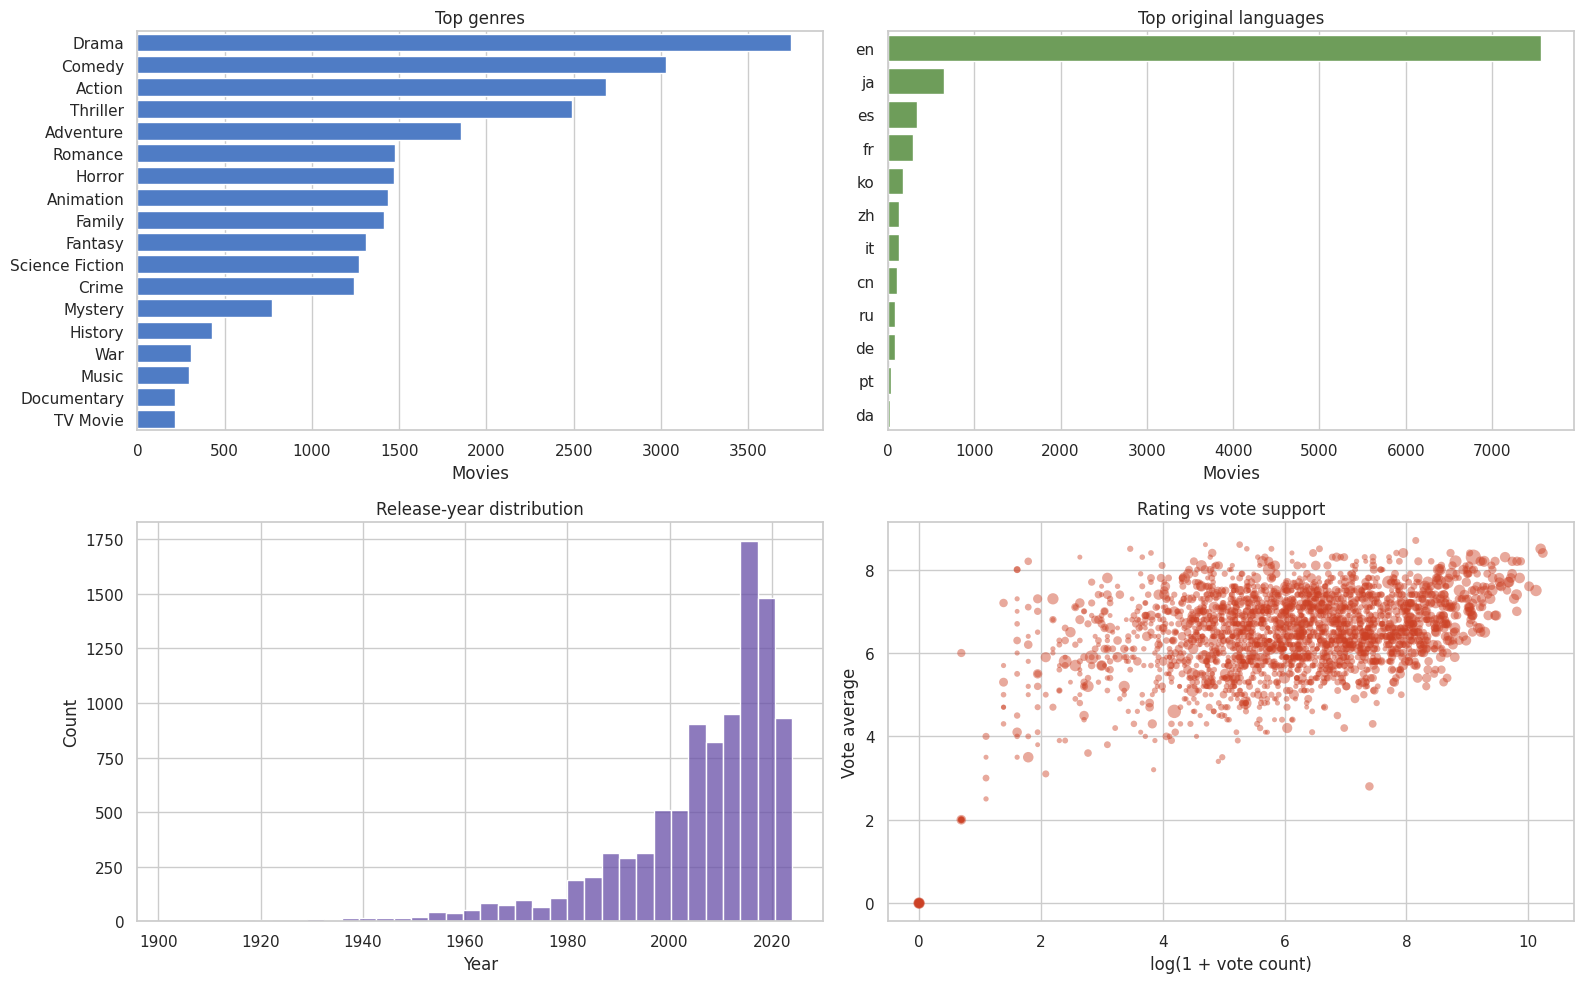

In [4]:
genre_counts = df["genres"].explode().value_counts().head(18)
language_counts = df["Original_Language"].value_counts().head(12)
plot_df = df.assign(
    log_vote_count=np.log1p(df["Vote_Count"]),
    log_popularity=np.log1p(df["Popularity"])
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=axes[0, 0], color="#3c78d8")
axes[0, 0].set_title("Top genres")
axes[0, 0].set_xlabel("Movies")
axes[0, 0].set_ylabel("")

sns.barplot(x=language_counts.values, y=language_counts.index, ax=axes[0, 1], color="#6aa84f")
axes[0, 1].set_title("Top original languages")
axes[0, 1].set_xlabel("Movies")
axes[0, 1].set_ylabel("")

sns.histplot(df["year"], bins=36, ax=axes[1, 0], color="#674ea7")
axes[1, 0].set_title("Release-year distribution")
axes[1, 0].set_xlabel("Year")

sample = plot_df.sample(min(2500, len(plot_df)), random_state=SEED)
sns.scatterplot(
    data=sample, x="log_vote_count", y="Vote_Average", size="log_popularity",
    sizes=(12, 120), alpha=0.45, linewidth=0, ax=axes[1, 1], color="#cc4125", legend=False
)
axes[1, 1].set_title("Rating vs vote support")
axes[1, 1].set_xlabel("log(1 + vote count)")
axes[1, 1].set_ylabel("Vote average")

plt.tight_layout()
plt.show()

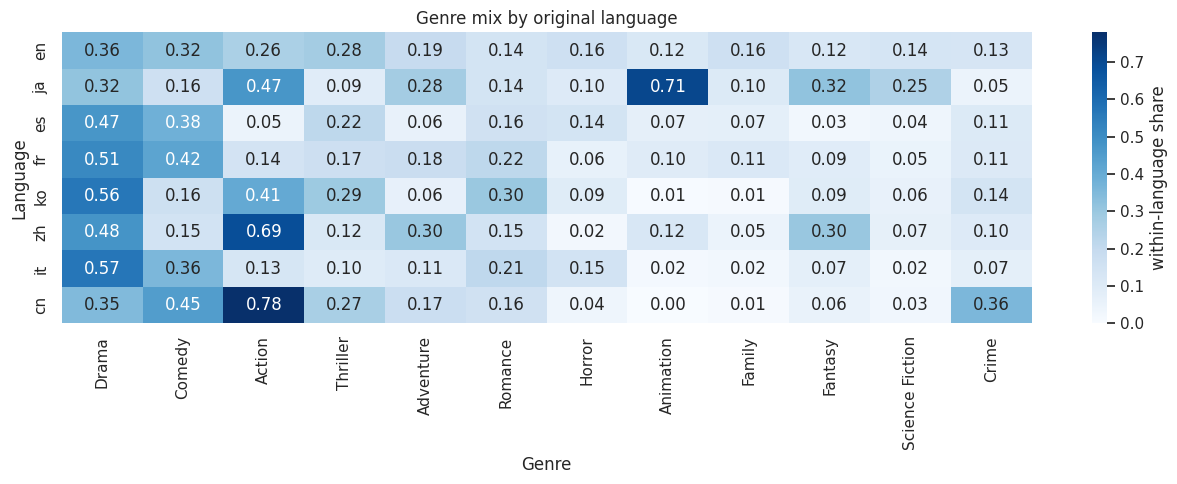

In [5]:
top_genres = genre_counts.head(12).index.tolist()
top_langs = language_counts.head(8).index.tolist()
heat = pd.DataFrame(0, index=top_langs, columns=top_genres, dtype=float)
for lang in top_langs:
    part = df[df["Original_Language"].eq(lang)]
    counts = part["genres"].explode().value_counts()
    heat.loc[lang] = [counts.get(g, 0) / max(len(part), 1) for g in top_genres]

plt.figure(figsize=(13, 5))
sns.heatmap(heat, cmap="Blues", annot=True, fmt=".2f", cbar_kws={"label": "within-language share"})
plt.title("Genre mix by original language")
plt.xlabel("Genre")
plt.ylabel("Language")
plt.tight_layout()
plt.show()

## Model Design

- **Content baseline:** TF-IDF over title, genres, language, and overview.
- **Hybrid retriever:** fuses lexical, latent/semantic, facet, and quality ranks with Reciprocal Rank Fusion.
- **Cross-lingual path:** uses multilingual E5 if available; otherwise falls back to LSA plus multilingual genre/language aliases.
- **Slate quality:** Maximal Marginal Relevance reduces near-duplicate recommendations.

In [6]:
def genre_text(genres):
    return " ".join(genres)


def weighted_movie_text(row):
    genres = genre_text(row["genres"])
    return " ".join([
        row["Title"], row["Title"],
        "genres", genres, genres, genres,
        "language", row["language_name"], row["Original_Language"],
        "overview", row["Overview"]
    ])


def embedding_text(kind, texts):
    if isinstance(texts, str):
        texts = [texts]
    if "e5" in EMBEDDING_MODEL_NAME.lower():
        prefix = "query: " if kind == "query" else "passage: "
        return [prefix + text for text in texts]
    return list(texts)


df["genre_text"] = df["genres"].map(genre_text)
df["lexical_text"] = df.apply(weighted_movie_text, axis=1)

word_vectorizer = TfidfVectorizer(
    stop_words="english", ngram_range=(1, 2), min_df=2, max_df=0.86,
    sublinear_tf=True, strip_accents="unicode", norm="l2"
)
char_vectorizer = TfidfVectorizer(
    analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_df=0.95,
    sublinear_tf=True, strip_accents="unicode", norm="l2"
)

X_word = word_vectorizer.fit_transform(df["lexical_text"])
X_char = char_vectorizer.fit_transform(df["lexical_text"])
X_lex = normalize(sparse.hstack([0.82 * X_word, 0.18 * X_char], format="csr"), norm="l2")

n_components = min(N_COMPONENTS, max(2, min(X_lex.shape) - 1))
svd = TruncatedSVD(n_components=n_components, random_state=SEED, n_iter=7)
X_lsa = normalize(svd.fit_transform(X_lex), norm="l2")

mlb = MultiLabelBinarizer()
X_genres = sparse.csr_matrix(mlb.fit_transform(df["genres"]).astype(float))
X_language = sparse.csr_matrix(pd.get_dummies(df["Original_Language"], dtype=float).to_numpy())
year_scaled = ((df["year"] - df["year"].min()) / (df["year"].max() - df["year"].min())).to_numpy().reshape(-1, 1)
X_year = sparse.csr_matrix(year_scaled)
X_facet = normalize(sparse.hstack([2.4 * X_genres, 0.7 * X_language, 0.25 * X_year], format="csr"), norm="l2")

semantic_model = None
X_dense = X_lsa
DENSE_BACKEND = f"LSA({n_components}) fallback"

if USE_SENTENCE_TRANSFORMER:
    try:
        from sentence_transformers import SentenceTransformer
        semantic_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
        passages = (df["Title"] + ". Genres: " + df["genre_text"] + ". " + df["Overview"]).tolist()
        X_dense = semantic_model.encode(
            embedding_text("passage", passages), batch_size=64, show_progress_bar=True,
            convert_to_numpy=True, normalize_embeddings=True
        )
        DENSE_BACKEND = EMBEDDING_MODEL_NAME
    except Exception as exc:
        print(f"Using LSA fallback because multilingual embeddings are unavailable: {type(exc).__name__}: {exc}")

print(f"TF-IDF matrix: {X_lex.shape}")
print(f"Facet matrix: {X_facet.shape}")
print(f"Dense backend: {DENSE_BACKEND} | dense shape: {X_dense.shape}")
print(f"LSA explained variance: {svd.explained_variance_ratio_.sum():.3f}")

Using LSA fallback because multilingual embeddings are unavailable: ModuleNotFoundError: No module named 'sentence_transformers'
TF-IDF matrix: (9827, 131609)
Facet matrix: (9827, 63)
Dense backend: LSA(128) fallback | dense shape: (9827, 128)
LSA explained variance: 0.177


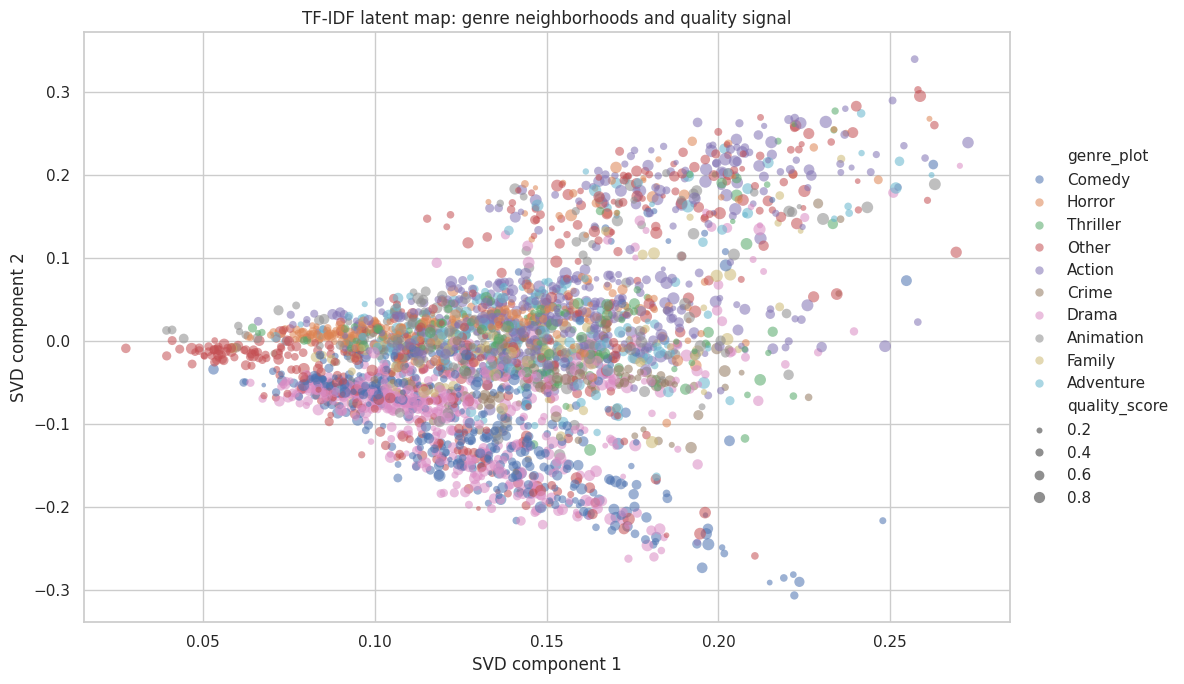

In [7]:
map_svd = TruncatedSVD(n_components=2, random_state=SEED, n_iter=7)
xy = map_svd.fit_transform(X_lex)
map_df = df[["Title", "primary_genre", "Original_Language", "quality_score"]].copy()
map_df["x"] = xy[:, 0]
map_df["y"] = xy[:, 1]
plot_sample = map_df.sample(min(3000, len(map_df)), random_state=SEED)
top_map_genres = plot_sample["primary_genre"].value_counts().head(9).index
plot_sample["genre_plot"] = np.where(plot_sample["primary_genre"].isin(top_map_genres), plot_sample["primary_genre"], "Other")

plt.figure(figsize=(12, 7))
sns.scatterplot(data=plot_sample, x="x", y="y", hue="genre_plot", size="quality_score", sizes=(10, 80), alpha=0.55, linewidth=0)
plt.title("TF-IDF latent map: genre neighborhoods and quality signal")
plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
plt.tight_layout()
plt.show()

## Recommender Core

The system returns ranked slates, not only nearest neighbors. That lets us tune relevance, catalog quality, language/genre filters, and diversity separately.

In [8]:
N = len(df)
quality_vector = df["quality_score"].to_numpy(dtype=float)
all_languages = set(df["Original_Language"])
GENRE_NORMALIZED = {re.sub(r"\s+", " ", g.lower()).strip(): g for g in mlb.classes_}


def strip_accents(text):
    return "".join(ch for ch in unicodedata.normalize("NFKD", str(text)) if not unicodedata.combining(ch))


def normalize_text(text):
    text = strip_accents(str(text).lower())
    text = re.sub(r"[^\w\s]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


GENRE_ALIASES = {
    "Action": ["action", "accion", "acao", "azione", "aktion", "боевик", "एक्शन"],
    "Adventure": ["adventure", "aventura", "aventure", "abenteuer", "冒険"],
    "Animation": ["animation", "animated", "anime", "animacion", "アニメ"],
    "Comedy": ["comedy", "comedia", "comedie", "komodie", "コメディ"],
    "Crime": ["crime", "criminal", "policier", "crimen", "krimi", "detective"],
    "Drama": ["drama", "drame", "social", "critica social", "character study"],
    "Family": ["family", "familia", "familial", "familie", "kids"],
    "Fantasy": ["fantasy", "fantasia", "fantastique", "fantasie", "ファンタジー"],
    "History": ["history", "historical", "historia", "historique", "geschichte"],
    "Horror": ["horror", "terror", "horreur", "ホラー"],
    "Mystery": ["mystery", "misterio", "mystere", "mistere", "謎"],
    "Romance": ["romance", "romantic", "romantica", "romantique", "love", "amor", "amour"],
    "Science Fiction": ["science fiction", "sci fi", "scifi", "ciencia ficcion", "sf"],
    "Thriller": ["thriller", "suspenso", "suspense", "spannung", "スリラー"],
    "War": ["war", "guerra", "guerre", "krieg"],
    "Western": ["western", "cowboy"],
}

LANGUAGE_ALIASES = {
    "en": ["english", "ingles", "anglais", "hollywood"],
    "ja": ["japanese", "japones", "japonais", "日本", "anime", "アニメ"],
    "es": ["spanish", "espanol", "español", "espagnol"],
    "fr": ["french", "frances", "francais", "français"],
    "ko": ["korean", "coreano", "coreana", "coreen", "coréen", "한국"],
    "zh": ["chinese", "chino", "chinois", "中文"],
    "cn": ["cantonese", "hong kong", "chinese"],
    "it": ["italian", "italiano", "italien"],
    "ru": ["russian", "ruso", "russe", "русский"],
    "de": ["german", "aleman", "allemand", "deutsch"],
    "pt": ["portuguese", "portugues", "portugais"],
    "hi": ["hindi", "bollywood", "हिंदी"],
}

LANGUAGE_ALIAS_TO_CODE = {}
for code, aliases in LANGUAGE_ALIASES.items():
    for alias in aliases + [code, LANGUAGE_NAMES.get(code, code)]:
        LANGUAGE_ALIAS_TO_CODE[normalize_text(alias)] = code


def minmax01(values):
    values = np.asarray(values, dtype=float)
    out = np.zeros_like(values, dtype=float)
    finite = np.isfinite(values)
    if not finite.any():
        return out
    lo, hi = values[finite].min(), values[finite].max()
    if hi > lo:
        out[finite] = (values[finite] - lo) / (hi - lo)
    return out


def matrix_scores(matrix, idx):
    if sparse.issparse(matrix):
        return (matrix @ matrix[idx].T).toarray().ravel()
    return np.asarray(matrix @ matrix[idx]).ravel()


def top_indices(scores, n=500, mask=None):
    scores = np.asarray(scores, dtype=float)
    if mask is None:
        mask = np.ones(len(scores), dtype=bool)
    values = np.where(mask & np.isfinite(scores), scores, -np.inf)
    available = int(np.isfinite(values).sum())
    if available == 0:
        return np.array([], dtype=int)
    n = min(int(n), available)
    if n >= len(values):
        order = np.argsort(-values)
        return order[np.isfinite(values[order])][:n]
    cand = np.argpartition(-values, n - 1)[:n]
    cand = cand[np.isfinite(values[cand])]
    return cand[np.argsort(-values[cand])]


def rrf_from_scores(scores, weight=1.0, rrf_k=60, top_k=800, mask=None):
    fused = np.zeros(N, dtype=float)
    if weight <= 0:
        return fused
    order = top_indices(scores, n=min(top_k or N, N), mask=mask)
    if len(order):
        ranks = np.arange(1, len(order) + 1)
        fused[order] = weight / (rrf_k + ranks)
    return fused


def alias_matches_query(normalized_query, alias):
    alias = normalize_text(alias)
    if not alias:
        return False
    if any(ord(ch) > 127 for ch in alias):
        return alias in normalized_query
    if " " in alias:
        return alias in normalized_query
    return alias in set(normalized_query.split())


def query_facets(query):
    q = normalize_text(query)
    genres = []
    languages = []
    for genre, aliases in GENRE_ALIASES.items():
        if genre in mlb.classes_ and any(alias_matches_query(q, alias) for alias in aliases):
            genres.append(genre)
    for alias, code in LANGUAGE_ALIAS_TO_CODE.items():
        # Natural-language queries should not treat short ISO codes as words.
        if code in all_languages and len(alias) > 2 and alias_matches_query(q, alias):
            languages.append(code)
    return sorted(set(genres)), sorted(set(languages))


def expand_query(query):
    genres, languages = query_facets(query)
    pieces = [query]
    if genres:
        pieces.extend(genres * 3)
    if languages:
        pieces.extend(([LANGUAGE_NAMES.get(code, code) for code in languages] + languages) * 2)
    return " ".join(map(str, pieces))


def query_lexical_vector(query):
    expanded = expand_query(query)
    q_word = word_vectorizer.transform([expanded])
    q_char = char_vectorizer.transform([expanded])
    return normalize(sparse.hstack([0.82 * q_word, 0.18 * q_char], format="csr"), norm="l2")


def query_lexical_scores(query):
    q_vec = query_lexical_vector(query)
    return (q_vec @ X_lex.T).toarray().ravel()


def query_dense_scores(query):
    if semantic_model is not None:
        emb = semantic_model.encode(
            embedding_text("query", query), convert_to_numpy=True,
            normalize_embeddings=True, show_progress_bar=False
        )[0]
        return np.asarray(X_dense @ emb).ravel()
    q_lsa = normalize(svd.transform(query_lexical_vector(query)), norm="l2")
    return np.asarray(X_dense @ q_lsa[0]).ravel()


def query_facet_scores(query):
    genres, languages = query_facets(query)
    scores = np.zeros(N, dtype=float)
    if genres:
        wanted = set(genres)
        scores += df["genres"].map(lambda gs: len(wanted & set(gs)) / len(wanted)).to_numpy(dtype=float)
    if languages:
        scores += 0.8 * df["Original_Language"].isin(languages).to_numpy(dtype=float)
    return scores, {"genres": genres, "languages": languages}


def normalize_genres(genres):
    if genres is None:
        return None
    if isinstance(genres, str):
        genres = [g.strip() for g in genres.split(",")]
    normalized = []
    for genre in genres:
        key = normalize_text(genre)
        if key in GENRE_NORMALIZED:
            normalized.append(GENRE_NORMALIZED[key])
        else:
            for canonical, aliases in GENRE_ALIASES.items():
                if any(normalize_text(alias) == key for alias in aliases):
                    normalized.append(canonical)
    return sorted(set(normalized)) or None


def normalize_languages(languages):
    if languages is None:
        return None
    if isinstance(languages, str):
        languages = [x.strip() for x in languages.split(",")]
    codes = []
    for language in languages:
        key = normalize_text(language)
        if key in all_languages:
            codes.append(key)
        elif key in LANGUAGE_ALIAS_TO_CODE:
            codes.append(LANGUAGE_ALIAS_TO_CODE[key])
    return sorted(set(code for code in codes if code in all_languages)) or None


def candidate_mask(languages=None, genres=None, min_votes=0, year_range=None, exclude=None):
    mask = df["Vote_Count"].ge(min_votes).to_numpy(dtype=bool)
    language_codes = normalize_languages(languages)
    if language_codes:
        mask &= df["Original_Language"].isin(language_codes).to_numpy(dtype=bool)
    wanted_genres = normalize_genres(genres)
    if wanted_genres:
        wanted = set(wanted_genres)
        mask &= df["genres"].map(lambda gs: bool(wanted & set(gs))).to_numpy(dtype=bool)
    if year_range is not None:
        start, end = year_range
        mask &= df["year"].between(start, end).to_numpy(dtype=bool)
    if exclude is not None:
        mask[np.array(list(exclude), dtype=int)] = False
    return mask


def normalize_title(title):
    return normalize_text(title)


TITLE_KEYS = df["Title"].map(normalize_title)
TITLE_KEY_VALUES = TITLE_KEYS.to_numpy()


def movie_label(idx):
    row = df.loc[int(idx)]
    return f"{row['Title']} ({row['year']})"


def resolve_title(title, year=None):
    key = normalize_title(title)
    candidate_idx = np.flatnonzero(TITLE_KEY_VALUES == key)
    if year is not None and len(candidate_idx):
        year_mask = df.loc[candidate_idx, "year"].eq(int(year)).to_numpy()
        candidate_idx = candidate_idx[year_mask]
    if len(candidate_idx) == 0:
        matches = difflib.get_close_matches(key, sorted(set(TITLE_KEY_VALUES)), n=6, cutoff=0.55)
        suggestions = []
        for match in matches:
            idxs = np.flatnonzero(TITLE_KEY_VALUES == match)
            if len(idxs):
                best = df.loc[idxs].sort_values(["Vote_Count", "Popularity"], ascending=False).index[0]
                suggestions.append(movie_label(best))
        raise ValueError(f"Title not found: {title}. Suggestions: {', '.join(suggestions) or 'none'}")
    best_idx = df.loc[candidate_idx].sort_values(["Vote_Count", "Popularity"], ascending=False).index[0]
    return int(best_idx)


MODE_WEIGHTS = {
    "content": {"lexical": 0.74, "facet": 0.26, "dense": 0.00, "quality": 0.00},
    "semantic": {"lexical": 0.15, "facet": 0.07, "dense": 0.78, "quality": 0.00},
    "hybrid": {"lexical": 0.34, "facet": 0.18, "dense": 0.36, "quality": 0.12},
}


def score_by_index(seed_idx, mode="hybrid", mask=None):
    mode = mode.lower()
    if mode not in MODE_WEIGHTS:
        raise ValueError(f"Unknown mode: {mode}. Choose from {list(MODE_WEIGHTS)}")
    if mask is None:
        mask = np.ones(N, dtype=bool)
    mask = mask.copy()
    mask[int(seed_idx)] = False
    weights = MODE_WEIGHTS[mode]

    lexical = matrix_scores(X_lex, seed_idx)
    dense = matrix_scores(X_dense, seed_idx)
    facet = matrix_scores(X_facet, seed_idx)

    fused = np.zeros(N, dtype=float)
    fused += rrf_from_scores(lexical, weights["lexical"], top_k=1000, mask=mask)
    fused += rrf_from_scores(dense, weights["dense"], top_k=1000, mask=mask)
    fused += rrf_from_scores(facet, weights["facet"], top_k=1000, mask=mask)
    fused += rrf_from_scores(quality_vector, weights["quality"], top_k=2500, mask=mask)

    raw_tiebreak = 0.003 * (
        0.40 * minmax01(lexical) + 0.35 * minmax01(dense) +
        0.20 * minmax01(facet) + 0.05 * quality_vector
    )
    fused += raw_tiebreak
    fused[~mask] = -np.inf
    return fused, {"lexical": lexical, "dense": dense, "facet": facet}


def score_from_query(query, mask=None):
    if mask is None:
        mask = np.ones(N, dtype=bool)
    lexical = query_lexical_scores(query)
    dense = query_dense_scores(query)
    facet, parsed = query_facet_scores(query)
    has_facets = np.any(facet > 0)

    weights = {"dense": 0.42, "lexical": 0.30, "facet": 0.18 if has_facets else 0.00, "quality": 0.10}
    if not has_facets:
        weights["dense"] += 0.10
        weights["lexical"] += 0.08

    fused = np.zeros(N, dtype=float)
    fused += rrf_from_scores(dense, weights["dense"], top_k=1200, mask=mask)
    fused += rrf_from_scores(lexical, weights["lexical"], top_k=1200, mask=mask)
    fused += rrf_from_scores(facet, weights["facet"], top_k=1200, mask=mask)
    fused += rrf_from_scores(quality_vector, weights["quality"], top_k=2500, mask=mask)
    fused += 0.003 * (0.45 * minmax01(dense) + 0.35 * minmax01(lexical) + 0.15 * minmax01(facet) + 0.05 * quality_vector)
    fused[~mask] = -np.inf
    return fused, {"lexical": lexical, "dense": dense, "facet": facet, "parsed": parsed}


def profile_vector_scores(liked_indices, disliked_indices=None):
    disliked_indices = disliked_indices or []
    liked_indices = list(map(int, liked_indices))
    disliked_indices = list(map(int, disliked_indices))

    dense_profile = X_dense[liked_indices].mean(axis=0)
    if disliked_indices:
        dense_profile = dense_profile - 0.60 * X_dense[disliked_indices].mean(axis=0)
    dense_profile = dense_profile / max(np.linalg.norm(dense_profile), 1e-12)
    dense_scores = np.asarray(X_dense @ dense_profile).ravel()

    lex_profile = X_lex[liked_indices].mean(axis=0)
    facet_profile = X_facet[liked_indices].mean(axis=0)
    if disliked_indices:
        lex_profile = lex_profile - 0.60 * X_lex[disliked_indices].mean(axis=0)
        facet_profile = facet_profile - 0.60 * X_facet[disliked_indices].mean(axis=0)
    lex_profile = normalize(sparse.csr_matrix(lex_profile), norm="l2")
    facet_profile = normalize(sparse.csr_matrix(facet_profile), norm="l2")
    lexical_scores = (lex_profile @ X_lex.T).toarray().ravel()
    facet_scores = (facet_profile @ X_facet.T).toarray().ravel()
    return lexical_scores, dense_scores, facet_scores


def score_from_likes(liked_titles, disliked_titles=None, mask=None):
    liked = [resolve_title(title) for title in liked_titles]
    disliked = [resolve_title(title) for title in (disliked_titles or [])]
    if mask is None:
        mask = np.ones(N, dtype=bool)
    mask = mask.copy()
    mask[np.array(liked + disliked, dtype=int)] = False

    lexical, dense, facet = profile_vector_scores(liked, disliked)
    fused = np.zeros(N, dtype=float)
    fused += rrf_from_scores(dense, 0.38, top_k=1200, mask=mask)
    fused += rrf_from_scores(lexical, 0.34, top_k=1200, mask=mask)
    fused += rrf_from_scores(facet, 0.18, top_k=1200, mask=mask)
    fused += rrf_from_scores(quality_vector, 0.10, top_k=2500, mask=mask)
    fused += 0.003 * (0.40 * minmax01(dense) + 0.35 * minmax01(lexical) + 0.20 * minmax01(facet) + 0.05 * quality_vector)
    fused[~mask] = -np.inf
    return fused, {"liked": liked, "disliked": disliked, "lexical": lexical, "dense": dense, "facet": facet}


def mmr_select(candidate_idx, relevance, top_n=10, diversity=0.25):
    candidate_idx = np.array(candidate_idx, dtype=int)
    if len(candidate_idx) <= top_n:
        return candidate_idx
    relevance_local = minmax01(relevance[candidate_idx])
    sim = np.asarray(X_dense[candidate_idx] @ X_dense[candidate_idx].T)
    sim = np.clip(sim, 0, 1)
    selected = []
    remaining = list(range(len(candidate_idx)))
    diversity = float(np.clip(diversity, 0, 0.95))

    while remaining and len(selected) < top_n:
        if not selected:
            pick_local = remaining[int(np.argmax(relevance_local[remaining]))]
        else:
            redundancy = sim[np.ix_(remaining, selected)].max(axis=1)
            score = (1 - diversity) * relevance_local[remaining] - diversity * redundancy
            pick_local = remaining[int(np.argmax(score))]
        selected.append(pick_local)
        remaining.remove(pick_local)
    return candidate_idx[selected]


def explain_pair(seed_idx, rec_idx):
    seed_genres = set(df.at[int(seed_idx), "genres"])
    rec_genres = set(df.at[int(rec_idx), "genres"])
    shared = sorted(seed_genres & rec_genres)
    bits = []
    if shared:
        bits.append("genre: " + ", ".join(shared[:3]))
    if df.at[int(seed_idx), "Original_Language"] == df.at[int(rec_idx), "Original_Language"]:
        bits.append("same language")
    year_gap = abs(int(df.at[int(seed_idx), "year"]) - int(df.at[int(rec_idx), "year"]))
    if year_gap <= 5:
        bits.append(f"{year_gap}y gap")
    return "; ".join(bits) or "semantic/content match"


def result_frame(indices, scores, seed_idx=None):
    out = df.loc[list(map(int, indices)), [
        "Title", "year", "Original_Language", "language_name", "Genre", "Vote_Average",
        "Vote_Count", "Popularity", "quality_score", "Poster_Url"
    ]].copy()
    out.insert(0, "rank", np.arange(1, len(out) + 1))
    out.insert(1, "score", np.round(scores[list(map(int, indices))], 6))
    if seed_idx is not None:
        out["reason"] = [explain_pair(seed_idx, idx) for idx in indices]
    return out.reset_index(drop=True)


def recommend_by_index(seed_idx, top_n=10, mode="hybrid", diversity=0.25, languages=None, genres=None,
                       min_votes=0, year_range=None, candidate_pool=500, return_indices=False):
    mask = candidate_mask(languages=languages, genres=genres, min_votes=min_votes, year_range=year_range, exclude=[seed_idx])
    scores, _ = score_by_index(int(seed_idx), mode=mode, mask=mask)
    candidates = top_indices(scores, n=candidate_pool, mask=np.isfinite(scores))
    selected = mmr_select(candidates, scores, top_n=top_n, diversity=diversity)
    if return_indices:
        return selected
    return result_frame(selected, scores, seed_idx=seed_idx)


def recommend_by_title(title, year=None, top_n=10, mode="hybrid", diversity=0.25, languages=None,
                       genres=None, min_votes=0, year_range=None, candidate_pool=500):
    seed_idx = resolve_title(title, year=year)
    print(f"Seed: {movie_label(seed_idx)} | mode={mode} | dense={DENSE_BACKEND}")
    return recommend_by_index(
        seed_idx, top_n=top_n, mode=mode, diversity=diversity, languages=languages,
        genres=genres, min_votes=min_votes, year_range=year_range, candidate_pool=candidate_pool
    )


def recommend_from_query(query, top_n=10, diversity=0.25, languages=None, genres=None,
                         min_votes=0, year_range=None, candidate_pool=600):
    mask = candidate_mask(languages=languages, genres=genres, min_votes=min_votes, year_range=year_range)
    scores, views = score_from_query(query, mask=mask)
    candidates = top_indices(scores, n=candidate_pool, mask=np.isfinite(scores))
    selected = mmr_select(candidates, scores, top_n=top_n, diversity=diversity)
    parsed = views["parsed"]
    print(f"Query: {query}")
    print(f"Parsed facets: genres={parsed['genres'] or 'none'} | languages={parsed['languages'] or 'none'} | dense={DENSE_BACKEND}")
    return result_frame(selected, scores)


def recommend_from_likes(liked_titles, disliked_titles=None, top_n=10, diversity=0.25, languages=None,
                         genres=None, min_votes=0, year_range=None, candidate_pool=600):
    mask = candidate_mask(languages=languages, genres=genres, min_votes=min_votes, year_range=year_range)
    scores, views = score_from_likes(liked_titles, disliked_titles=disliked_titles, mask=mask)
    candidates = top_indices(scores, n=candidate_pool, mask=np.isfinite(scores))
    selected = mmr_select(candidates, scores, top_n=top_n, diversity=diversity)
    liked_labels = ", ".join(movie_label(idx) for idx in views["liked"])
    print(f"Liked profile: {liked_labels}")
    if views["disliked"]:
        print("Downweighted: " + ", ".join(movie_label(idx) for idx in views["disliked"]))
    return result_frame(selected, scores)


def show_recommendations(results, title="Recommendations"):
    cards = []
    for _, row in results.iterrows():
        poster = html.escape(str(row["Poster_Url"]))
        name = html.escape(str(row["Title"]))
        meta = html.escape(f"{int(row['year'])} | {row['language_name']} | {row['Vote_Average']:.1f}")
        genres = html.escape(str(row["Genre"]))
        cards.append(f"""
        <div style="width:150px; margin:8px 10px 14px 0; display:inline-block; vertical-align:top; font-family:Arial, sans-serif;">
            <img src="{poster}" style="width:150px; height:225px; object-fit:cover; border-radius:6px; background:#eee;" />
            <div style="font-weight:700; font-size:13px; line-height:1.25; margin-top:6px;">{int(row['rank'])}. {name}</div>
            <div style="font-size:12px; color:#555; line-height:1.25;">{meta}</div>
            <div style="font-size:11px; color:#777; line-height:1.2;">{genres}</div>
        </div>
        """)
    display(HTML(f"<h3 style='font-family:Arial, sans-serif;'>{html.escape(title)}</h3><div>{''.join(cards)}</div>"))

## Title Recommendations

The baseline is intentionally simple. The hybrid version adds latent semantics, quality priors, and diversity-aware slate construction.

In [11]:
content_spider = recommend_by_title("Spider-Man: No Way Home", mode="content", top_n=10, diversity=0.10, min_votes=20)
display(content_spider.drop(columns=["Poster_Url"]))
show_recommendations(content_spider, "Content baseline: Spider-Man: No Way Home")

Seed: Spider-Man: No Way Home (2021) | mode=content | dense=LSA(128) fallback


ValueError: assignment destination is read-only

In [10]:
hybrid_batman = recommend_by_title("The Batman", mode="hybrid", top_n=10, diversity=0.28, min_votes=50)
display(hybrid_batman.drop(columns=["Poster_Url"]))
show_recommendations(hybrid_batman, "Hybrid slate: The Batman")

Seed: The Batman (2022) | mode=hybrid | dense=LSA(128) fallback


ValueError: assignment destination is read-only

In [ ]:
profile_recs = recommend_from_likes(
    liked_titles=["The Batman", "Joker", "Se7en"],
    disliked_titles=["Batman & Robin"],
    top_n=10, diversity=0.32, min_votes=50
)
display(profile_recs.drop(columns=["Poster_Url"]))
show_recommendations(profile_recs, "Profile: dark crime thrillers")

Liked profile: The Batman (2022), Joker (2019), Se7en (1995)
Downweighted: Batman & Robin (1997)


,rank,score,Title,year,Original_Language,language_name,Genre,Vote_Average,Vote_Count,Popularity,quality_score
0,1,0.016928,Insomnia,2002,en,English,"Crime, Mystery, Thriller",6.9,3670,19.097,0.745800
1,2,0.015294,Felony,2014,en,English,"Mystery, Thriller, Crime",5.7,138,14.140,0.213465
2,3,0.014205,Wander,2020,en,English,"Thriller, Crime, Mystery",5.4,208,15.376,0.197586
3,4,0.012574,Exposed,2016,en,English,"Drama, Crime, Thriller, Mystery",4.9,401,19.640,0.212751
4,5,0.012483,Mindhunters,2004,en,English,"Mystery, Thriller, Crime",6.5,897,24.121,0.568251
5,6,0.012449,Mother,2009,ko,Korean,"Crime, Drama, Mystery, Thriller",7.8,976,16.558,0.716633
6,7,0.012353,Texas Killing Fields,2011,en,English,"Drama, Thriller, Crime, Mystery",5.8,375,15.070,0.211680
7,8,0.012346,Klute,1971,en,English,"Mystery, Thriller, Crime",6.8,284,18.412,0.528185
8,9,0.012049,Beckett,2021,en,English,"Crime, Mystery, Thriller",6.4,469,98.796,0.552099
9,10,0.011983,88 Minutes,2007,en,English,"Crime, Mystery, Thriller",5.7,857,17.455,0.224084


## Cross-Lingual Queries

When multilingual E5 is available, non-English queries map into the same vector space as English overviews. Without it, aliases still recover common genre and language intent.

In [ ]:
queries = [
    "pelicula coreana de suspenso con critica social",
    "日本のアニメ ファンタジー 冒険",
    "thriller policier sombre avec un tueur en serie",
]

for query in queries:
    recs = recommend_from_query(query, top_n=8, diversity=0.30, min_votes=30)
    display(recs.drop(columns=["Poster_Url"]))
    show_recommendations(recs, f"Query: {query}")

Query: pelicula coreana de suspenso con critica social
Parsed facets: genres=['Drama', 'Thriller'] | languages=['ko'] | dense=intfloat/multilingual-e5-small


,rank,score,Title,year,Original_Language,language_name,Genre,Vote_Average,Vote_Count,Popularity,quality_score
0,1,0.013794,Commitment,2013,ko,Korean,"Drama, Action, Thriller",7.3,96,16.511,0.463231
1,2,0.012814,Parasite,2019,ko,Korean,"Comedy, Thriller, Drama",8.5,13240,108.442,0.985469
2,3,0.011876,1987: When the Day Comes,2017,ko,Korean,"Drama, History, Thriller",8.0,95,18.978,0.537415
3,4,0.011408,Peligro en tu mirada,2021,es,Spanish,"Drama, Thriller",7.1,36,26.761,0.485690
4,5,0.011359,Kingdom: Ashin of the North,2021,ko,Korean,"Drama, Fantasy, Thriller",7.6,355,33.645,0.728943
5,6,0.010857,A Bittersweet Life,2005,ko,Korean,"Action, Drama, Crime",7.5,627,16.570,0.661794
6,7,0.010857,Joint Security Area,2000,ko,Korean,"War, Drama, Thriller, Action",7.9,435,17.009,0.660718
7,8,0.010852,Sex Is Zero,2002,ko,Korean,"Comedy, Drama",5.9,71,25.711,0.380169


Query: 日本のアニメ ファンタジー 冒険
Parsed facets: genres=['Adventure', 'Animation', 'Fantasy'] | languages=['ja'] | dense=intfloat/multilingual-e5-small


,rank,score,Title,year,Original_Language,language_name,Genre,Vote_Average,Vote_Count,Popularity,quality_score
0,1,0.015643,Kabaneri of the Iron Fortress: The Battle of Unato,2019,ja,Japanese,"Animation, Action, Fantasy, Adventure",7.1,43,76.131,0.561481
1,2,0.014939,Kiki's Delivery Service,1989,ja,Japanese,"Animation, Family, Fantasy, Adventure",7.8,2931,51.313,0.922743
2,3,0.014465,Tales from Earthsea,2006,ja,Japanese,"Animation, Fantasy, Adventure",6.6,1012,19.064,0.585390
3,4,0.014314,Nausicaä of the Valley of the Wind,1984,ja,Japanese,"Adventure, Animation, Fantasy",7.9,2600,44.530,0.914157
4,5,0.013421,The Boy and the Beast,2015,ja,Japanese,"Animation, Fantasy, Action, Adventure, Drama",8.0,1161,56.152,0.887443
5,6,0.012538,Pom Poko,1994,ja,Japanese,"Adventure, Animation, Fantasy",7.2,737,25.513,0.732060
6,7,0.012111,Ainbo: Spirit of the Amazon,2021,en,English,"Adventure, Animation, Family, Fantasy",7.1,285,188.484,0.722530
7,8,0.011859,Yu☆Gi☆Oh!,1999,ja,Japanese,"Adventure, Animation, Fantasy",7.0,50,13.891,0.347848


Query: thriller policier sombre avec un tueur en serie
Parsed facets: genres=['Crime', 'Thriller'] | languages=none | dense=intfloat/multilingual-e5-small


,rank,score,Title,year,Original_Language,language_name,Genre,Vote_Average,Vote_Count,Popularity,quality_score
0,1,0.013984,The Trust,2016,en,English,"Crime, Thriller",5.0,365,19.168,0.213898
1,2,0.012960,Bent,2018,en,English,"Thriller, Crime",5.3,127,16.770,0.236021
2,3,0.012601,Restless,2022,fr,French,"Action, Thriller, Crime",5.9,107,1468.377,0.466574
3,4,0.011805,Taking Lives,2004,en,English,"Crime, Thriller",6.4,1233,17.251,0.409576
4,5,0.011720,A Better Tomorrow II,1987,zh,Chinese,"Action, Crime, Thriller",7.1,165,15.842,0.480108
5,6,0.011188,Ms .45,1981,en,English,"Crime, Thriller",6.6,213,16.238,0.434563
6,7,0.011175,Last Looks,2021,en,English,"Action, Crime, Thriller, Mystery",6.3,114,33.582,0.451392
7,8,0.010721,Under Suspicion,2000,en,English,"Thriller, Crime, Drama",6.1,350,13.484,0.225959


## Proxy Validation

There is no user-item interaction log, so we cannot claim true offline relevance. This proxy audit checks whether slates preserve genres, avoid mono-lists, keep quality stable, and cover the catalog.

In [12]:
def intra_list_diversity(indices):
    indices = list(map(int, indices))
    if len(indices) < 2:
        return np.nan
    sim = np.asarray(X_dense[indices] @ X_dense[indices].T)
    tri = sim[np.triu_indices(len(indices), k=1)]
    return float(1 - np.clip(tri, 0, 1).mean())


def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / max(len(a | b), 1)


def bootstrap_ci(values, n_boot=500, seed=SEED):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    means = [rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_boot)]
    return float(values.mean()), float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))


def evaluate_mode(mode, sample_size=180, k=10, diversity=0.25):
    rng = np.random.default_rng(SEED)
    eligible = np.flatnonzero(df["Vote_Count"].ge(50).to_numpy())
    seeds = rng.choice(eligible, size=min(sample_size, len(eligible)), replace=False)
    rows = []
    all_recs = []

    for seed_idx in seeds:
        rec_idx = recommend_by_index(
            int(seed_idx), mode=mode, top_n=k, diversity=diversity,
            min_votes=10, candidate_pool=420, return_indices=True
        )
        all_recs.extend(rec_idx.tolist())
        seed_genres = set(df.at[int(seed_idx), "genres"])
        rec_genres = [set(df.at[int(i), "genres"]) for i in rec_idx]
        rows.append({
            "seed_idx": int(seed_idx),
            "genre_hit_rate": np.mean([bool(seed_genres & gs) for gs in rec_genres]),
            "genre_jaccard": np.mean([jaccard(seed_genres, gs) for gs in rec_genres]),
            "same_language_rate": np.mean(df.loc[rec_idx, "Original_Language"].eq(df.at[int(seed_idx), "Original_Language"])),
            "mean_quality": df.loc[rec_idx, "quality_score"].mean(),
            "mean_vote_average": df.loc[rec_idx, "Vote_Average"].mean(),
            "intra_list_diversity": intra_list_diversity(rec_idx),
        })

    details = pd.DataFrame(rows)
    coverage = len(set(all_recs)) / len(df)
    return details, coverage


summary_records = []
eval_details = {}
for mode in ["content", "semantic", "hybrid"]:
    details, coverage = evaluate_mode(mode)
    eval_details[mode] = details
    for metric in ["genre_hit_rate", "genre_jaccard", "same_language_rate", "mean_quality", "mean_vote_average", "intra_list_diversity"]:
        mean, lo, hi = bootstrap_ci(details[metric])
        summary_records.append({"mode": mode, "metric": metric, "mean": mean, "ci_low": lo, "ci_high": hi})
    summary_records.append({"mode": mode, "metric": "catalog_coverage", "mean": coverage, "ci_low": np.nan, "ci_high": np.nan})

summary = pd.DataFrame(summary_records)
pivot = summary.pivot(index="metric", columns="mode", values="mean").loc[
    ["genre_hit_rate", "genre_jaccard", "same_language_rate", "mean_quality", "mean_vote_average", "intra_list_diversity", "catalog_coverage"]
]
display(pivot.round(3))

ValueError: assignment destination is read-only

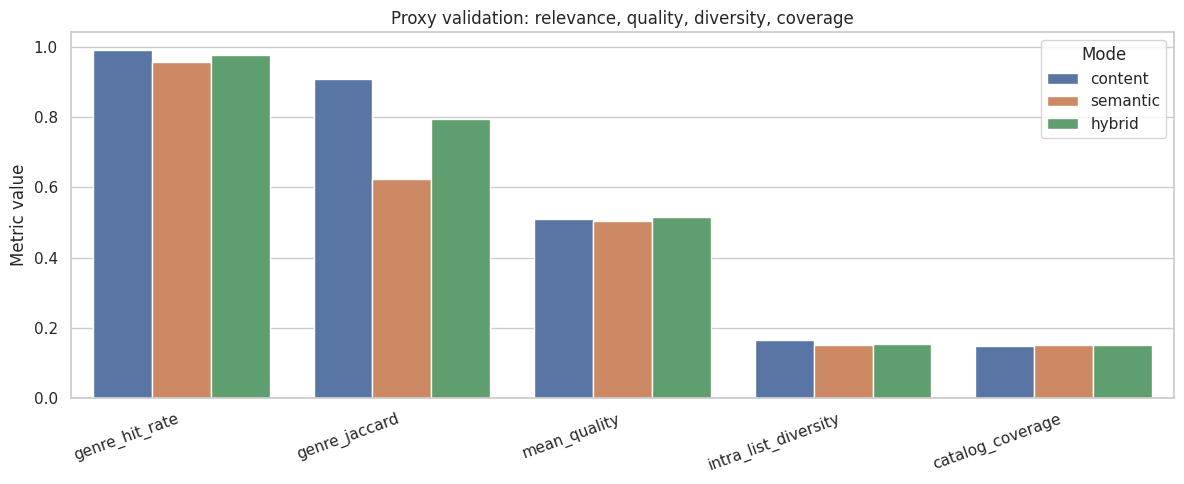

In [ ]:
plot_metrics = ["genre_hit_rate", "genre_jaccard", "mean_quality", "intra_list_diversity", "catalog_coverage"]
plot_summary = summary[summary["metric"].isin(plot_metrics)].copy()

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_summary, x="metric", y="mean", hue="mode")
plt.title("Proxy validation: relevance, quality, diversity, coverage")
plt.xlabel("")
plt.ylabel("Metric value")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Mode")
plt.tight_layout()
plt.show()